# Chapter 9: Searching the Future

A controller can spend its planning budget exploring every continuation or use a heuristic to focus on promising routes. The heuristic buys speed by estimating remaining cost. If it exaggerates the wrong route's cost, the search can stop at a more expensive goal while a cheaper possibility waits in the queue.

This notebook exposes both the search trace and a full-graph audit. A* uses the supplied heuristic; a separate reverse shortest-path computation establishes the true remaining costs inside this finite graph. The diagnostic can therefore distinguish helpful guidance from misleading confidence. It also accounts for heuristic evaluations, because computing a clever estimate is not free merely because the path chart omits that expense.

**Outcome:** Execute A* and audit supplied heuristic admissibility and cost.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

A* orders queued states by f(n)=g(n)+h(n), where g is the best discovered path cost from the start and h estimates remaining cost. An admissible heuristic satisfies h(n)<=d*(n,goal). A consistent heuristic satisfies h(u)<=c(u,v)+h(v) for every edge and h(goal)=0.

With nonnegative costs and an admissible heuristic, a search that reopens improved states can stop when the goal is popped and recover an optimal path. Consistency is a stronger local condition that simplifies the behavior of expanded states. The implementation permits reopening by inserting a state again whenever its best g improves; obsolete queue entries are skipped.

The audit computes exact remaining costs using Dijkstra's algorithm on reversed edges. This is feasible because the teaching graph is fully known. It does not mean a deployed search gets an optimal heuristic for free. Path cost, expansion count, and declared heuristic expense are separate metrics with separate units. A faster search can still consume more total compute if each heuristic call is expensive.

## A calculation you can run

Register nodes and nonnegative weighted directed edges. Give every node a finite nonnegative heuristic. The function first calculates exact graph distances for diagnostic comparison, then runs A* using the supplied values. It records each expanded node's g and f, reconstructs the first popped goal path, and counts heuristic calls.

The plot shows the g cost of successive expansions. It is a search-order trace, not a monotonic convergence curve. Consult the returned path cost and exact optimal cost together. In the changed case only B's heuristic rises. Predict which goal will be popped first and whether the admissibility check will pass. Keep the separate heuristic-total-cost metric when comparing implementations.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 9
inputs = {'nodes': ['S', 'A', 'B', 'G'],
 'start': 'S',
 'goal': 'G',
 'edges': [{'from': 'S', 'to': 'A', 'cost': 1},
           {'from': 'A', 'to': 'G', 'cost': 4},
           {'from': 'S', 'to': 'B', 'cost': 2},
           {'from': 'B', 'to': 'G', 'cost': 1}],
 'heuristic': {'S': 3, 'A': 4, 'B': 1, 'G': 0},
 'heuristic_cost': 0.1}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 9: astar-audit
Does this heuristic help search without hiding a cheaper route?
Evidence: constructed teaching example

Calculated quantities:
{
  "path": [
    "S",
    "B",
    "G"
  ],
  "path_cost": 3.0,
  "optimal_cost": 3.0,
  "admissible": true,
  "consistent": true,
  "expansions": 3,
  "heuristic_calls": 4,
  "heuristic_total_cost": 0.4
}

Interpretation:
A* stops at the first popped goal and reopens improved states. The exact reverse shortest-path check detects misleading supplied heuristics.

Assumptions:
- Finite graph with nonnegative edge costs.
- Heuristic costs are separate from path costs.

Limitations:
- An inadmissible heuristic can return a suboptimal goal.
- Full-graph heuristic auditing can cost more than the search itself.

Execution: completed locally; constructed inputs are not deployment measurements.


The default shortest route is S,B,G with cost 2+1=3. The heuristic matches true remaining distances and is both admissible and consistent. A* expands toward B and reaches the cheaper goal.

In the changed case h(B)=10 exceeds B's true remaining cost 1. The A branch looks cheaper to the queue, so the first popped goal follows S,A,G and costs 5. The exact graph optimum remains 3. The algorithm has not disproved A*; the supplied heuristic violated the condition needed for its optimality guarantee. The audit makes that violation visible beside the result.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


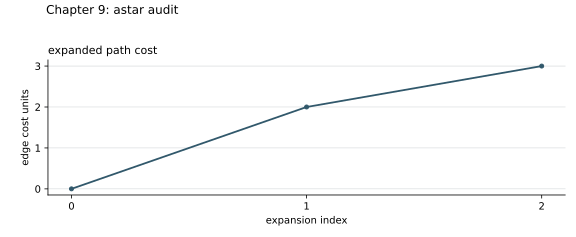

In [3]:
display(SVG(figure_svg(report)))

**Figure 9.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

An inadmissible heuristic can still return an optimal path on some graphs. That coincidence does not validate its contract. Conversely, a zero heuristic can be perfectly valid while offering no guidance beyond uniform-cost search. Evaluate correctness conditions separately from observed expansion savings.

The full-graph diagnostic itself has a cost and requires knowledge that may not exist in an open-ended planning problem. Do not claim the audit certifies an unknown environment. Its scope is the supplied finite graph and its declared edges.

A path can also be cheaper in edge units while more expensive in wall time, authority, or tool use. If those quantities matter, encode a justified cost model or report them separately. Adding incompatible units into one number without a valuation rule makes an apparently optimal path meaningless.

Chapter 9: astar-audit
Does this heuristic help search without hiding a cheaper route?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "path": [
    "S",
    "A",
    "G"
  ],
  "path_cost": 5.0,
  "optimal_cost": 3.0,
  "admissible": false,
  "consistent": false,
  "expansions": 3,
  "heuristic_calls": 4,
  "heuristic_total_cost": 0.4
}

Interpretation:
A* stops at the first popped goal and reopens improved states. The exact reverse shortest-path check detects misleading supplied heuristics.

Assumptions:
- Finite graph with nonnegative edge costs.
- Heuristic costs are separate from path costs.

Limitations:
- An inadmissible heuristic can return a suboptimal goal.
- Full-graph heuristic auditing can cost more than the search itself.

Execution: completed locally; constructed inputs are not deployment measurements.


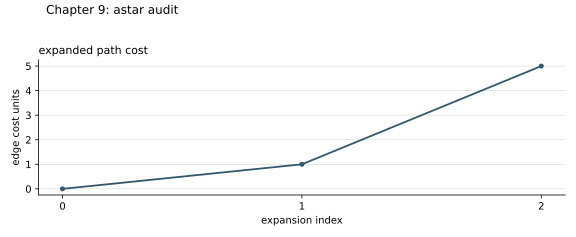

In [4]:
changed_inputs = {'nodes': ['S', 'A', 'B', 'G'],
 'start': 'S',
 'goal': 'G',
 'edges': [{'from': 'S', 'to': 'A', 'cost': 1},
           {'from': 'A', 'to': 'G', 'cost': 4},
           {'from': 'S', 'to': 'B', 'cost': 2},
           {'from': 'B', 'to': 'G', 'cost': 1}],
 'heuristic': {'S': 3, 'A': 4, 'B': 10, 'G': 0},
 'heuristic_cost': 0.1}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 9.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer graph uses a zero heuristic. A* becomes uniform-cost search and finds source,middle,target with cost 4 instead of the direct cost 7. This is a useful baseline: correctness does not depend on a sophisticated heuristic.

For reader data, preserve directed costs and distinguish unavailable edges from expensive edges. If you propose a heuristic, explain why it is a lower bound or label it as an unguaranteed guide. Compare its returned path with a small exact case and account for computation expense. Use graph reachability first when the main question is permission rather than cheapest continuation.

In [5]:
transfer_inputs = {'nodes': ['source', 'middle', 'target'],
 'start': 'source',
 'goal': 'target',
 'edges': [{'from': 'source', 'to': 'middle', 'cost': 2},
           {'from': 'middle', 'to': 'target', 'cost': 2},
           {'from': 'source', 'to': 'target', 'cost': 7}],
 'heuristic': {'source': 0, 'middle': 0, 'target': 0},
 'heuristic_cost': 0}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 9: astar-audit
Does this heuristic help search without hiding a cheaper route?
Evidence: constructed transfer example

Calculated quantities:
{
  "path": [
    "source",
    "middle",
    "target"
  ],
  "path_cost": 4.0,
  "optimal_cost": 4.0,
  "admissible": true,
  "consistent": true,
  "expansions": 3,
  "heuristic_calls": 4,
  "heuristic_total_cost": 0.0
}

Interpretation:
A* stops at the first popped goal and reopens improved states. The exact reverse shortest-path check detects misleading supplied heuristics.

Assumptions:
- Finite graph with nonnegative edge costs.
- Heuristic costs are separate from path costs.

Limitations:
- An inadmissible heuristic can return a suboptimal goal.
- Full-graph heuristic auditing can cost more than the search itself.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **nodes:** Unique graph identifiers.
- **start:** Registered search start.
- **goal:** Registered goal.
- **edges:** Directed from/to identifiers with finite nonnegative cost.
- **heuristic:** Object mapping each node to a nonnegative estimated remaining cost.
- **heuristic_cost:** Nonnegative declared cost of one heuristic evaluation, separate from path cost.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch09.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 9: astar-audit
Does this heuristic help search without hiding a cheaper route?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "path": [
    "source",
    "middle",
    "target"
  ],
  "path_cost": 4.0,
  "optimal_cost": 4.0,
  "admissible": true,
  "consistent": true,
  "expansions": 3,
  "heuristic_calls": 4,
  "heuristic_total_cost": 0.0
}

Interpretation:
A* stops at the first popped goal and reopens improved states. The exact reverse shortest-path check detects misleading supplied heuristics.

Assumptions:
- Finite graph with nonnegative edge costs.
- Heuristic costs are separate from path costs.

Limitations:
- An inadmissible heuristic can return a suboptimal goal.
- Full-graph heuristic auditing can cost more than the search itself.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. What is the default optimal path cost?

2. Which changed heuristic condition fails?

3. What does h=0 produce?

Answers: [separate solutions](../solutions/ch09.md). Try the calculation before opening them.

## Summary

A* combines accumulated cost with a remaining-cost estimate. Its trace is useful only when interpreted with heuristic conditions and computation expense. The default reaches the optimum; the changed heuristic hides the cheaper branch; the transfer case establishes a zero-heuristic baseline. The audit applies to a fully supplied finite graph. It checks a mathematical condition without estimating real-world edge accuracy or granting permission to traverse a route.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-09-astar-audit`](../skills/maa-09-astar-audit/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 9.1

![Equation 9.1](../assets/math/d644bc5f6d134538bbc7.svg)

Equation (9.1) gives the cost of the best route that is forced to pass through a particular vertex.

Add the cheapest way of getting to the vertex to the cheapest way of finishing from it.

LaTeX source, preserved for inspection:

```latex
f(v) \;=\; g(v) \;+\; h(v).
\tag{9.1}
```

### Equation 9.2

![Equation 9.2](../assets/math/c87fd983fba2133d2416.svg)

Equation (9.2) is the computable stand-in for Equation (9.1), and it is what the search actually sorts on.

Add what the search has already spent reaching the vertex to what it guesses finishing will cost.

LaTeX source, preserved for inspection:

```latex
\hat f(v) \;=\; \hat g(v) \;+\; \hat h(v).
\tag{9.2}
```

### Equation 9.3

![Equation 9.3](../assets/math/0363a1925aa679905892.svg)

Equation (9.3) is the condition under which the search cannot be talked out of the best path.

Never guess that finishing will cost more than it actually will.

LaTeX source, preserved for inspection:

```latex
\hat h(v) \;\le\; h(v) \qquad \text{for every vertex } v.
\tag{9.3}
```

### Equation 9.4

![Equation 9.4](../assets/math/b63e0576c12f18c007c1.svg)

Equation (9.4) requires the estimate to be consistent with itself from one vertex to the next.

The true cost of getting from one vertex to another, plus the estimate at the second, must be at least the estimate at the first.

LaTeX source, preserved for inspection:

```latex
h(u,v) \;+\; \hat h(v) \;\ge\; \hat h(u).
\tag{9.4}
```